# ManifoldGuard Performance Visualization
This notebook provides a comprehensive visual analysis of the ManifoldGuard framework, including baseline comparisons, sensitivity analyses, and qualitative model performance profiles.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

# Setup paths to access internal manifoldguard package
REPO_ROOT = Path(os.getcwd()).resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from manifoldguard.data import generate_synthetic_scores
from manifoldguard.evaluation import evaluate_experiment, _evaluate_episode
from manifoldguard.ensemble import train_ensemble, predict_new_model
from manifoldguard.episodes import simulate_new_model_episodes

plt.style.use('ggplot')
print("Environment initialized.")

Environment initialized.


## 1. Baseline Comparison
Comparing ManifoldGuard (MF + Conformal) against simpler baselines like Mean Filling and Nearest Neighbors.

Loading metrics from: summary_table.csv


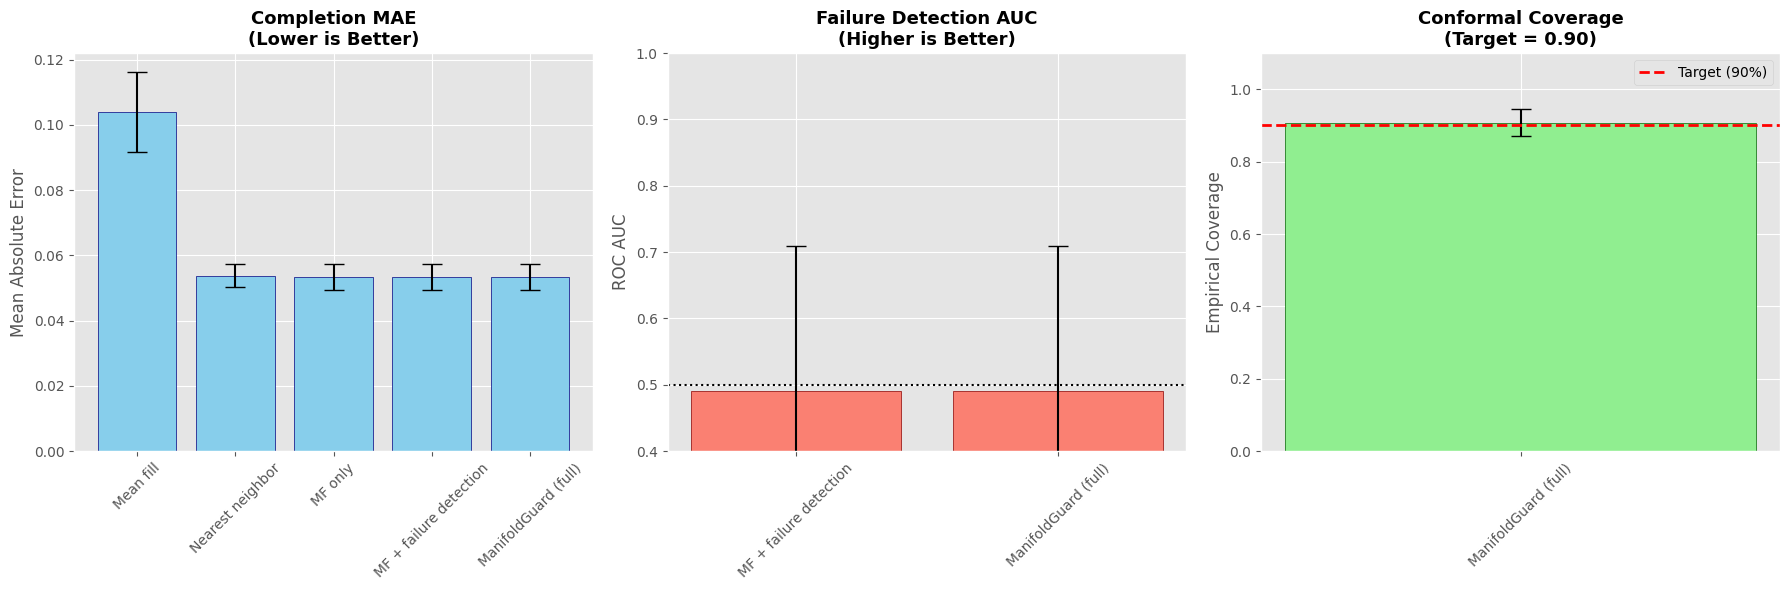

In [30]:
csv_path = 'summary_table.csv'
if not os.path.exists(csv_path):
    csv_path = str(REPO_ROOT / "results" / "baseline_comparison" / "summary_table.csv")

print(f"Loading metrics from: {csv_path}")
df = pd.read_csv(csv_path)

# Set up the figure and axes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Plot Completion MAE
axes[0].bar(df['method'], df['completion_mae_mean'], yerr=df['completion_mae_std'], capsize=7, color='skyblue', edgecolor='navy')
axes[0].set_title('Completion MAE\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].tick_params(axis='x', rotation=45)

# 2. Plot Failure AUC
auc_df = df.dropna(subset=['failure_auc_mean'])
if not auc_df.empty:
    axes[1].bar(auc_df['method'], auc_df['failure_auc_mean'], yerr=auc_df['failure_auc_std'], capsize=7, color='salmon', edgecolor='darkred')
    axes[1].set_title('Failure Detection AUC\n(Higher is Better)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('ROC AUC')
    axes[1].axhline(0.5, color='black', linestyle=':', label='Random Guess')
    axes[1].set_ylim(0.4, 1.0)
    axes[1].tick_params(axis='x', rotation=45)

# 3. Plot Conformal Coverage
cov_df = df.dropna(subset=['conformal_coverage_mean'])
if not cov_df.empty:
    axes[2].bar(cov_df['method'], cov_df['conformal_coverage_mean'], yerr=cov_df['conformal_coverage_std'], capsize=7, color='lightgreen', edgecolor='darkgreen')
    axes[2].set_title('Conformal Coverage\n(Target = 0.90)', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('Empirical Coverage')
    axes[2].axhline(0.9, color='red', linestyle='--', linewidth=2, label='Target (90%)')
    axes[2].set_ylim(0, 1.1)
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Sensitivity Analysis: Observed Fraction
Visualizing how performance scales as we reveal more information about the target model.

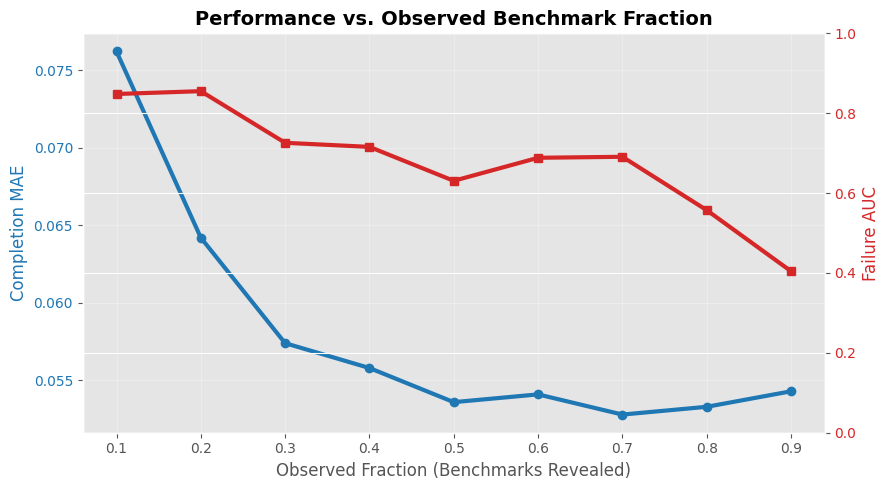

In [27]:
ablation_path = REPO_ROOT / "results" / "ablations" / "ablation_table.csv"
df_abl = pd.read_csv(ablation_path)
frac_df = df_abl[df_abl["ablation"] == "observed_fraction"].copy()
frac_df["setting"] = frac_df["setting"].astype(float)
frac_df = frac_df.sort_values("setting")

fig, ax1 = plt.subplots(figsize=(9, 5))

color = 'tab:blue'
ax1.set_xlabel('Observed Fraction (Benchmarks Revealed)')
ax1.set_ylabel('Completion MAE', color=color)
ax1.plot(frac_df['setting'], frac_df['completion_mae'], marker='o', color=color, linewidth=3, label='MAE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Failure AUC', color=color)
ax2.plot(frac_df['setting'], frac_df['failure_auc'], marker='s', color=color, linewidth=3, label='AUC')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)

plt.title('Performance vs. Observed Benchmark Fraction', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

## 3. Reliability Assessment: Risk Stratification
Proving that the "Risk Score" (OOD Probability) is a reliable lead indicator of actual completion error.

C:\Users\natha\AppData\Local\Temp\ipykernel_30196\3560134670.py:32: RuntimeWarning: Mean of empty slice.
  bin_means = [maes[(probs >= bins[i]) & (probs < bins[i+1])].mean() for i in range(len(bins)-1)]
C:\Users\natha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


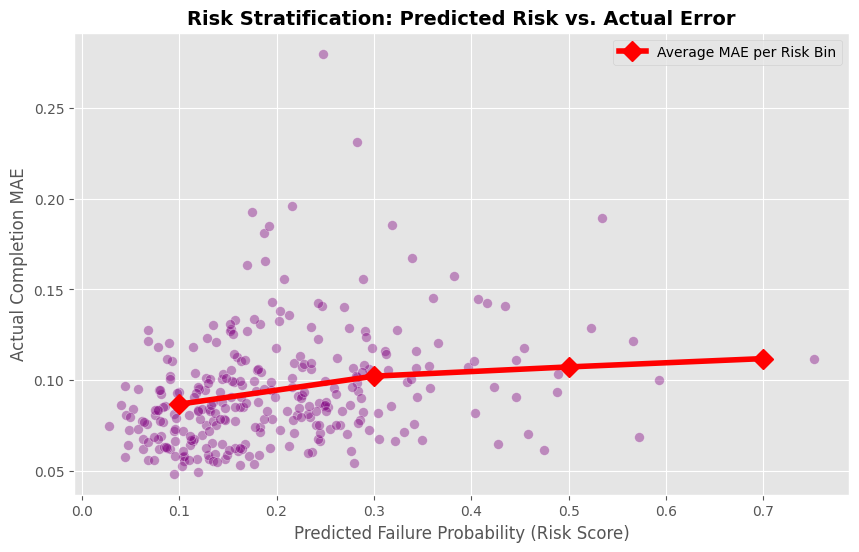

In [31]:
# Generate simulation data
seed = 42
matrix_obj = generate_synthetic_scores(num_models=100, num_benchmarks=35, seed=seed)
matrix = matrix_obj.values
train_matrix = matrix[:70]
test_matrix = matrix[70:]

ensemble = train_ensemble(train_matrix, ensemble_size=5, rank=4, epochs=300)
episodes = simulate_new_model_episodes(test_matrix, episodes_per_model=10, observed_fraction=0.3, seed=seed+1)
results = [_evaluate_episode(ep, ensemble, 1e-2) for ep in episodes]

maes = np.array([r.hidden_mae for r in results])
features = np.vstack([r.features for r in results])
probs = np.zeros(len(results))

# Simple LR to map manifold features to failure probability
threshold = np.percentile(maes, 80)
labels = (maes >= threshold).astype(int)
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, val_idx in kf.split(features):
    clf = LogisticRegression(max_iter=1000)
    clf.fit(features[train_idx], labels[train_idx])
    probs[val_idx] = clf.predict_proba(features[val_idx])[:, 1]

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(probs, maes, alpha=0.4, color='purple', edgecolors='white', s=50)

# Binned average trend line
bins = np.linspace(0, 1, 6)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = [maes[(probs >= bins[i]) & (probs < bins[i+1])].mean() for i in range(len(bins)-1)]
plt.plot(bin_centers, bin_means, color='red', marker='D', linewidth=4, markersize=10, label='Average MAE per Risk Bin')

plt.xlabel('Predicted Failure Probability (Risk Score)', fontsize=12)
plt.ylabel('Actual Completion MAE', fontsize=12)
plt.title('Risk Stratification: Predicted Risk vs. Actual Error', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

## 4. Qualitative Example: microsoft/Phi-3.5-mini-instruct
Detailed model profile extracted from a live evaluation episode showing true vs. predicted benchmarks with 90% confidence intervals.

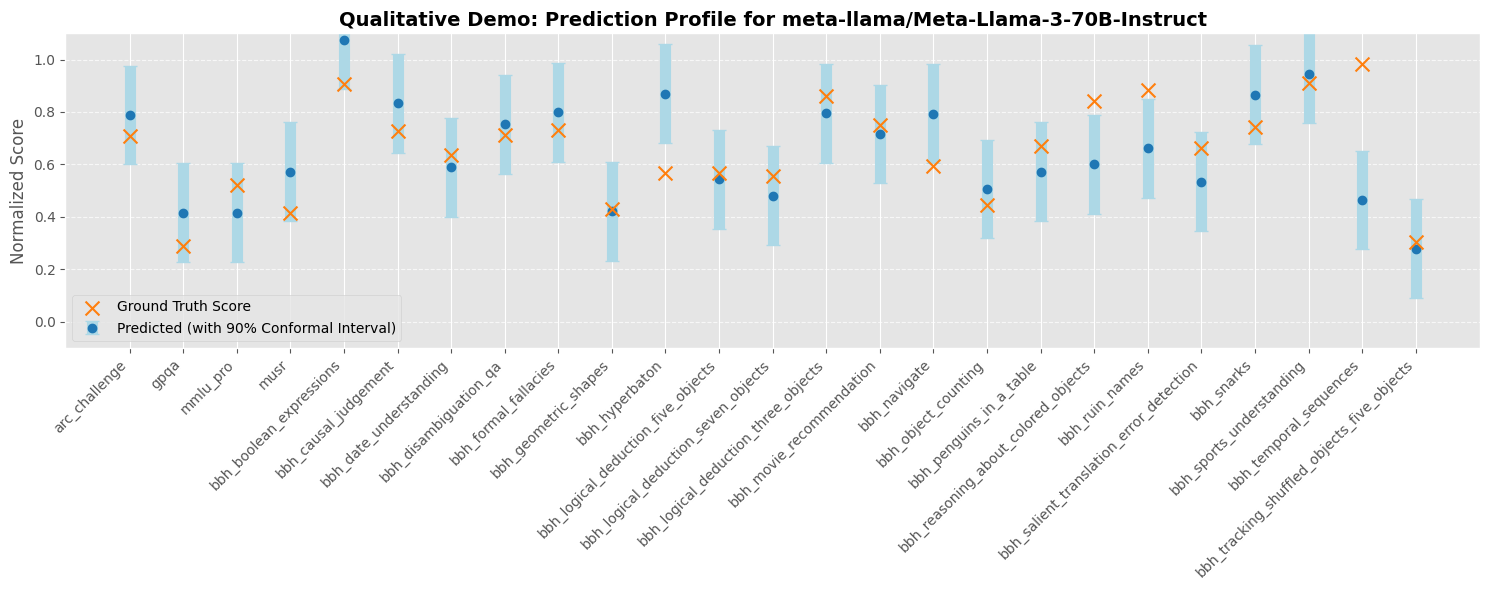

In [34]:
report_path = REPO_ROOT / "results" / "demo" / "demo_report.json"
if not report_path.exists():
    print(f"Warning: {report_path} not found. Run scripts/run_demo.py first.")
    data = []
    model_name = "Unknown"
else:
    import json
    with open(report_path, "r") as f:
        report = json.load(f)
    model_name = report.get("model_name", "Unknown")
    data = report.get("hidden_predictions", [])
if data:
    # Limit to top 25 benchmarks for readability if many were evaluated (e.g. --show-all)
    plot_data = data[:25] if len(data) > 25 else data
    names = [d["benchmark"] for d in plot_data]
    true_vals = [d["true_score"] for d in plot_data]
    pred_vals = [d["predicted_score"] for d in plot_data]
    low_vals = [d["interval_lower"] for d in plot_data]
    high_vals = [d["interval_upper"] for d in plot_data]
    x = np.arange(len(plot_data))
    errors = [pred_vals[i] - low_vals[i] for i in range(len(plot_data))]
    plt.figure(figsize=(15, 6))
    plt.errorbar(x, pred_vals, yerr=errors, fmt='o', color='tab:blue', 
                 capsize=5, ecolor='lightblue', elinewidth=8, 
                 label='Predicted (with 90% Conformal Interval)')
    plt.scatter(x, true_vals, color='tab:orange', marker='x', s=100, 
                label='Ground Truth Score', zorder=5)
    plt.xticks(x, names, rotation=45, ha="right")
    plt.ylabel("Normalized Score")
    plt.title(f"Qualitative Demo: Prediction Profile for {model_name}", fontsize=14, fontweight='bold')
    plt.ylim(-0.1, 1.1)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot. Please run scripts/run_demo.py successfully.")